# Notebook 5 — Baseline Model Building & Comparison

This notebook trains all baseline regression models using the modular
`src/` pipeline, tracks the best-performing pipeline, and saves it
along with the comparison results.

In [ ]:
#Imports
import sys
from pathlib import Path

# Add project root to sys.path so `src` is importable
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import time
import pandas as pd
import joblib

from src.preprocessing import create_preprocessor
from src.model_factory import build_models
from src.evaluation import evaluate_regression_model

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [3]:
#Load Dataset
DATA_DIR = Path("../data/processed")

df = pd.read_csv(DATA_DIR / "featured_train.csv")

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(f"Dataset Shape : {df.shape}")

df.head()

Dataset Loaded Successfully
Dataset Shape : (10462, 13)


,Airline,Source,Destination,Total_Stops,Price,Journey_Day,Journey_Month,Journey_Weekday,Departure_Hour,Departure_Minute,Arrival_Hour,Arrival_Minute,Duration_Minutes
0,IndiGo,Banglore,New Delhi,0,3897,24,3,6,22,20,1,10,170
1,Air India,Kolkata,Banglore,2,7662,1,5,2,5,50,13,15,445
2,Jet Airways,Delhi,Cochin,2,13882,9,6,6,9,25,4,25,1140
3,IndiGo,Kolkata,Banglore,1,6218,12,5,6,18,5,23,30,325
4,IndiGo,Banglore,New Delhi,1,13302,1,3,4,16,50,21,35,285


In [4]:
#Train-Test Split
X = df.drop(columns=["Price"])
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")


Training Samples : 8369
Testing Samples  : 2093


In [5]:
#Build Preprocessor
preprocessor = create_preprocessor(X_train)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [6]:
# Build Candidate Models
models = build_models()

print(f"Total models to train: {len(models)}")
list(models.keys())

Total models to train: 8


['Linear Regression',
 'Decision Tree',
 'Random Forest',
 'Gradient Boosting',
 'Extra Trees',
 'XGBoost',
 'LightGBM',
 'CatBoost']

In [7]:
#Train & Evaluate All Models
start_time = time.time()

results = []
trained_pipelines = {}

best_pipeline = None
best_model_name = None
best_r2 = float("-inf")

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    metrics = evaluate_regression_model(y_test, predictions)
    metrics["Model"] = model_name

    results.append(metrics)
    trained_pipelines[model_name] = pipeline

    print(
        f"{model_name:<20}"
        f"R²: {metrics['R2 Score']:.4f} | "
        f"RMSE: {metrics['RMSE']:.2f}"
    )

    if metrics["R2 Score"] > best_r2:
        best_r2 = metrics["R2 Score"]
        best_pipeline = pipeline
        best_model_name = model_name

print("\nAll baseline models trained successfully!")

end_time = time.time()
print(f"\nExecution Time : {end_time - start_time:.2f} seconds")

Linear Regression   R²: 0.5867 | RMSE: 2935.56
Decision Tree       R²: 0.7096 | RMSE: 2460.60
Random Forest       R²: 0.8125 | RMSE: 1977.22
Gradient Boosting   R²: 0.7535 | RMSE: 2267.25
Extra Trees         R²: 0.7801 | RMSE: 2141.18
XGBoost             R²: 0.8368 | RMSE: 1844.79


c:\Users\arushi khare\OneDrive\Desktop\Flight-Price-Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM            R²: 0.8295 | RMSE: 1885.63
CatBoost            R²: 0.8019 | RMSE: 2032.55

All baseline models trained successfully!

Execution Time : 7.59 seconds


In [8]:
#Results Comparison Table
results_df = (
    pd.DataFrame(results)
    .sort_values(by="R2 Score", ascending=False)
    .reset_index(drop=True)
)

results_df.style.format({
    "MAE": "{:.2f}",
    "RMSE": "{:.2f}",
    "R2 Score": "{:.4f}"
})

,MAE,RMSE,R2 Score,Model
0,1200.56,1844.79,0.8368,XGBoost
1,1194.64,1885.63,0.8295,LightGBM
2,1178.04,1977.22,0.8125,Random Forest
3,1356.03,2032.55,0.8019,CatBoost
4,1236.52,2141.18,0.7801,Extra Trees
5,1526.66,2267.25,0.7535,Gradient Boosting
6,1422.12,2460.60,0.7096,Decision Tree
7,1995.30,2935.56,0.5867,Linear Regression


In [9]:
#Best Model Summary
print("=" * 60)
print(f"Best Baseline Model : {best_model_name}")
print(f"R² Score : {results_df.iloc[0]['R2 Score']:.4f}")
print(f"MAE      : {results_df.iloc[0]['MAE']:.2f}")
print(f"RMSE     : {results_df.iloc[0]['RMSE']:.2f}")
print("=" * 60)

Best Baseline Model : XGBoost
R² Score : 0.8368
MAE      : 1200.56
RMSE     : 1844.79


In [10]:
#Save Results & Best Pipeline
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(RESULTS_DIR / "baseline_results.csv", index=False)

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    best_pipeline,
    MODEL_DIR / "best_baseline_model.pkl"
)

print("Results saved successfully.")
print(f"Best pipeline ({best_model_name}) saved to {MODEL_DIR / 'best_baseline_model.pkl'}")

Results saved successfully.
Best pipeline (XGBoost) saved to ..\models\best_baseline_model.pkl


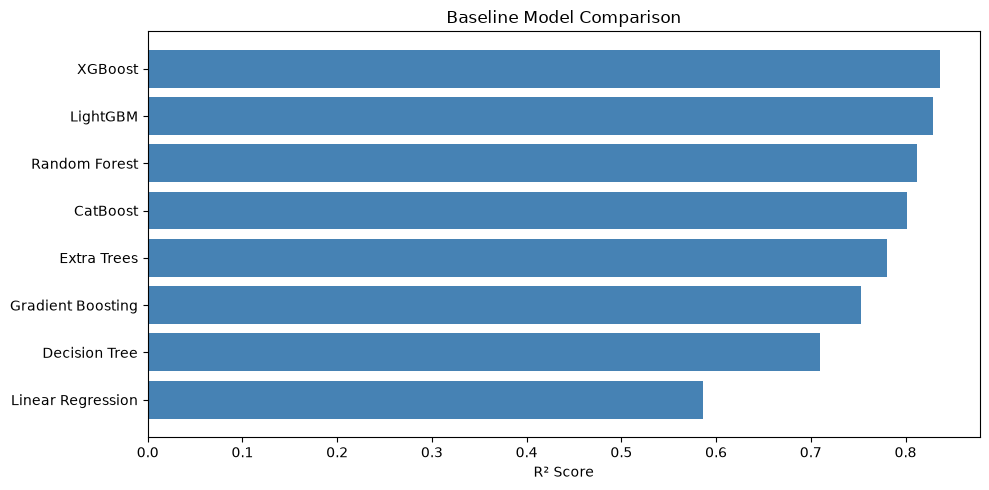

In [12]:
#Visual Comparison
import matplotlib.pyplot as plt

SCREENSHOTS_DIR = Path("../screenshots")
SCREENSHOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))
plt.barh(results_df["Model"], results_df["R2 Score"], color="steelblue")
plt.xlabel("R² Score")
plt.title("Baseline Model Comparison")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(SCREENSHOTS_DIR / "baseline_r2_comparison.png", dpi=150)
plt.show()